# Exercise 1 – Easy: Hadamard Measurement

### Objective

Measure a Hadamard-superposition qubit using 100, 1000 and 10000 shots and observe how the measured probability converges to 0.5.

### Theory

The Hadamard gate converts the initial state |0⟩ into an equal superposition of |0⟩ and |1⟩.

Therefore, the theoretical probability of measuring 0 is 0.5 and the probability of measuring 1 is 0.5.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

simulator = AerSimulator()

In [6]:
shots_list = [100, 1000, 10000]
p0, p1 = [], []

for shots in shots_list:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()

    p0.append(counts.get('0', 0) / shots)
    p1.append(counts.get('1', 0) / shots)

    print("Shots:", shots, counts)

Shots: 100 {'1': 48, '0': 52}
Shots: 1000 {'0': 497, '1': 503}
Shots: 10000 {'1': 5033, '0': 4967}


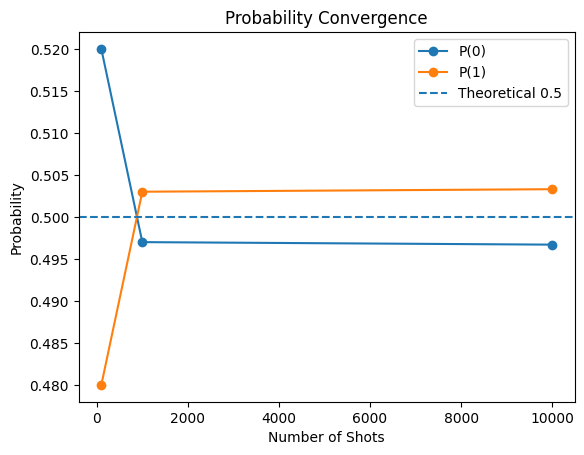

In [7]:
plt.plot(shots_list, p0, marker='o', label='P(0)')
plt.plot(shots_list, p1, marker='o', label='P(1)')
plt.axhline(0.5, linestyle='--', label='Theoretical 0.5')

plt.xlabel("Number of Shots")
plt.ylabel("Probability")
plt.title("Probability Convergence")
plt.legend()
plt.show()

### Observation

The measured probabilities fluctuate more with fewer shots. As the number of
shots increases, the probabilities of 0 and 1 approach the theoretical value
of 0.5. This demonstrates statistical convergence.